In [19]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy.sparse as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import average_precision_score
import os

DEVICE      = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ============================================================
# PATHS
# ============================================================
FEATURES_CSV = "../Features/EPIC/P01_04_vgg_fused_features.csv"
LABELS_CSV   = "../Labels/EPIC/P01_04_vgg_fused_labeled.csv"
MODEL_PATH   = "../Model/EPIC/P01_04_vgg_fused_model.pt"
SAVE_DIR     = "../Sensitivity/EPIC/"
os.makedirs(SAVE_DIR, exist_ok=True)

# ============================================================
# LOAD
# ============================================================
features_df  = pd.read_csv(FEATURES_CSV)
labels_df    = pd.read_csv(LABELS_CSV)
features     = features_df.drop(
                   columns=["frame_id"]).values.astype(np.float32)
labels       = labels_df.drop(
                   columns=["frame_id"]).values.astype(np.float32)
T, FEATURE_DIM = features.shape
NUM_CLASSES    = labels.shape[1]

# ============================================================
# MODEL
# ============================================================
class Classifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.net(x)

model = Classifier(FEATURE_DIM, NUM_CLASSES).to(DEVICE)
model.load_state_dict(
    torch.load(MODEL_PATH, map_location=DEVICE),
    strict=True
)
model.eval()
print("Model loaded.")

# ============================================================
# METRICS
# ============================================================
def compute_mAP(y_true, y_pred, num_classes):
    AP = []
    for c in range(num_classes):
        if y_true[:, c].sum() == 0:
            continue
        ap = average_precision_score(
            y_true[:, c], y_pred[:, c])
        AP.append(ap)
    return np.mean(AP)

# ============================================================
# GRAPH — default k=5
# ============================================================
def build_transition_matrix(features, k=5):
    feat_t = torch.from_numpy(features).to(DEVICE)
    feat_t = F.normalize(feat_t, dim=1)
    S      = torch.matmul(
        feat_t, feat_t.T).cpu().numpy()
    A      = np.zeros_like(S)
    for i in range(len(S)):
        idx       = np.argpartition(S[i], -k)[-k:]
        A[i, idx] = S[i, idx]
    A      = A * A.T
    np.fill_diagonal(A, 0.0)
    row_sum = A.sum(axis=1, keepdims=True)
    P       = A / np.maximum(row_sum, 1e-8)
    return torch.from_numpy(
        P.astype(np.float32)).to(DEVICE)

def carrw(logits, P_tensor, alpha, steps):
    Y           = torch.sigmoid(logits)
    confidence  = torch.abs(Y - 0.5) * 2
    uncertainty = 1 - confidence
    for _ in range(steps):
        Y = Y + alpha * uncertainty * (
            torch.matmul(P_tensor, Y) - Y)
    return torch.clamp(Y, 0, 1)

# Base logits and graph
X_tensor  = torch.from_numpy(
    features).float().to(DEVICE)
with torch.no_grad():
    logits    = model(X_tensor)

P_default = build_transition_matrix(features, k=5)
y_true    = labels

# ============================================================
# GRID SEARCH — α × K_rw
# ============================================================
alpha_range = [0.1, 0.2, 0.3, 0.4, 0.5,
               0.6, 0.7, 0.8, 0.9]
krw_range   = [1, 2, 3, 4, 5, 6, 7, 8,
               9, 10, 12, 15]

mAP_grid    = np.zeros(
    (len(alpha_range), len(krw_range)))

print("\n" + "="*60)
print("Grid Search: α × K_rw → mAP")
print("="*60)

for i, alpha in enumerate(alpha_range):
    for j, krw in enumerate(krw_range):
        with torch.no_grad():
            preds = carrw(
                logits, P_default,
                alpha=alpha, steps=krw
            ).cpu().numpy()
        mAP = compute_mAP(
            y_true, preds, NUM_CLASSES)
        mAP_grid[i, j] = mAP
        print(f"  α={alpha:.1f}  "
              f"K_rw={krw:2d}  →  "
              f"mAP={mAP:.4f}")

# Find optimal
best_idx   = np.unravel_index(
    np.argmax(mAP_grid), mAP_grid.shape)
best_alpha = alpha_range[best_idx[0]]
best_krw   = krw_range[best_idx[1]]
best_mAP   = mAP_grid[best_idx]
print(f"\nOptimal: α*={best_alpha}, "
      f"K_rw*={best_krw}, "
      f"mAP*={best_mAP:.4f}")

# Save grid
grid_df = pd.DataFrame(
    mAP_grid,
    index=[f"α={a}" for a in alpha_range],
    columns=[f"K={k}" for k in krw_range]
)
grid_df.to_csv(
    f"{SAVE_DIR}sensitivity_grid.csv")
print("Saved grid results.")

# ============================================================
# ALSO DO k sensitivity separately (line plot)
# ============================================================
print("\n" + "="*60)
print("k-NN Sensitivity (separate line plot)")
print("="*60)

k_values = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15]
k_mAP    = []

for k in k_values:
    P_k  = build_transition_matrix(features, k=k)
    with torch.no_grad():
        preds = carrw(
            logits, P_k,
            alpha=0.5, steps=5
        ).cpu().numpy()
    mAP  = compute_mAP(y_true, preds, NUM_CLASSES)
    k_mAP.append(mAP)
    print(f"  k={k:2d} → mAP={mAP:.4f}")

best_k = k_values[np.argmax(k_mAP)]
print(f"\nBest k = {best_k}")

pd.DataFrame({
    "k": k_values, "mAP": k_mAP
}).to_csv(
    f"{SAVE_DIR}sensitivity_k.csv",
    index=False)


Device: cuda


C:\Users\PAWANESH\AppData\Local\Temp\ipykernel_13952\460227962.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(MODEL_PATH, map_location=DEVICE),


Model loaded.

Grid Search: α × K_rw → mAP
  α=0.1  K_rw= 1  →  mAP=0.8520
  α=0.1  K_rw= 2  →  mAP=0.8524
  α=0.1  K_rw= 3  →  mAP=0.8526
  α=0.1  K_rw= 4  →  mAP=0.8530
  α=0.1  K_rw= 5  →  mAP=0.8532
  α=0.1  K_rw= 6  →  mAP=0.8534
  α=0.1  K_rw= 7  →  mAP=0.8536
  α=0.1  K_rw= 8  →  mAP=0.8538
  α=0.1  K_rw= 9  →  mAP=0.8539
  α=0.1  K_rw=10  →  mAP=0.8541
  α=0.1  K_rw=12  →  mAP=0.8544
  α=0.1  K_rw=15  →  mAP=0.8550
  α=0.2  K_rw= 1  →  mAP=0.8524
  α=0.2  K_rw= 2  →  mAP=0.8530
  α=0.2  K_rw= 3  →  mAP=0.8535
  α=0.2  K_rw= 4  →  mAP=0.8538
  α=0.2  K_rw= 5  →  mAP=0.8541
  α=0.2  K_rw= 6  →  mAP=0.8544
  α=0.2  K_rw= 7  →  mAP=0.8548
  α=0.2  K_rw= 8  →  mAP=0.8551
  α=0.2  K_rw= 9  →  mAP=0.8554
  α=0.2  K_rw=10  →  mAP=0.8556
  α=0.2  K_rw=12  →  mAP=0.8560
  α=0.2  K_rw=15  →  mAP=0.8565
  α=0.3  K_rw= 1  →  mAP=0.8527
  α=0.3  K_rw= 2  →  mAP=0.8535
  α=0.3  K_rw= 3  →  mAP=0.8540
  α=0.3  K_rw= 4  →  mAP=0.8544
  α=0.3  K_rw= 5  →  mAP=0.8550
  α=0.3  K_rw= 6  →  mAP=0.85

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


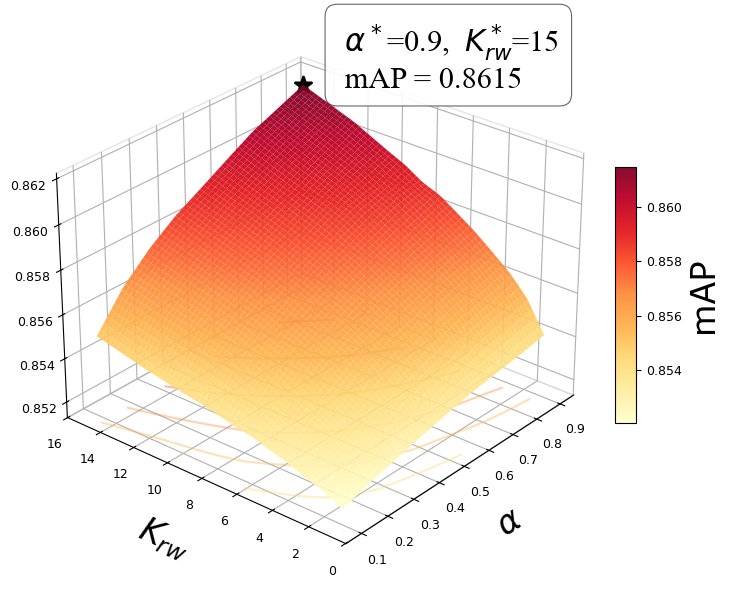

Saved.


In [28]:
# ============================================================
# CLEAN & BEAUTIFUL 3D SURFACE PLOT
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors

fig = plt.figure(figsize=(8, 6))
fig.patch.set_facecolor("white")

ax  = fig.add_subplot(111, projection='3d')
ax.set_facecolor("white")

# ============================================================
# SMOOTH SURFACE — interpolate for smoother look
# ============================================================
from scipy.interpolate import RegularGridInterpolator

interp     = RegularGridInterpolator(
    (alpha_range, krw_range),
    mAP_grid,
    method='linear'
)

# Fine grid for smooth surface
alpha_fine = np.linspace(
    min(alpha_range), max(alpha_range), 60)
krw_fine   = np.linspace(
    min(krw_range), max(krw_range), 60)

A_fine, K_fine = np.meshgrid(
    alpha_fine, krw_fine, indexing='ij')

pts        = np.array([
    A_fine.ravel(),
    K_fine.ravel()
]).T
Z_fine     = interp(pts).reshape(A_fine.shape)

# ============================================================
# PLOT SURFACE
# ============================================================
surf = ax.plot_surface(
    A_fine, K_fine, Z_fine,
    cmap='YlOrRd',
    edgecolor='none',
    alpha=0.95,
    antialiased=True,
    rcount=60, ccount=60
)

# ============================================================
# CONTOUR LINES ON SURFACE — adds depth
# ============================================================
ax.contour(
    A_fine, K_fine, Z_fine,
    zdir='z',
    offset=Z_fine.min() - 0.001,
    cmap='YlOrRd',
    alpha=0.4,
    levels=8
)

# ============================================================
# OPTIMAL POINT
# ============================================================
ax.scatter(
    [best_alpha], [best_krw], [best_mAP],
    color='black', s=150,
    zorder=10, marker='*',
    linewidths=2.0,
    label=f"Optimal"
)

# Clean annotation box
ax.text(
    best_alpha + 0.15,
    best_krw + 0.15,
    best_mAP - 0.001,
    f" $\\alpha^*$={best_alpha},  "
    f"$K_{{rw}}^*$={best_krw}\n"
    f" mAP = {best_mAP:.4f}",
    fontsize=22,
    color='black',
    fontfamily='Times New Roman',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        edgecolor='#555555',
        alpha=0.9,
        linewidth=0.8
    )
)

# ============================================================
# AXES STYLING
# ============================================================
ax.set_xlabel(
    "$\\alpha$",
    fontsize=24,
    labelpad=12,
    fontfamily='Verdana'
)
ax.set_ylabel(
    "$K_{rw}$",
    fontsize=24,
    labelpad=12,
    fontfamily='Verdana'
)
ax.set_zlabel(
    "mAP",
    fontsize=24,
    labelpad=12,
    fontfamily='Verdana'
)
ax.zaxis.set_rotate_label(False)
ax.zaxis.label.set_rotation(90)

# Tick formatting
ax.xaxis.set_major_formatter(
    ticker.FormatStrFormatter('%.1f'))
ax.yaxis.set_major_formatter(
    ticker.FormatStrFormatter('%d'))
ax.zaxis.set_major_formatter(
    ticker.FormatStrFormatter('%.3f'))

ax.tick_params(
    axis='both', labelsize=9)

# Clean pane colors
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#cccccc')
ax.yaxis.pane.set_edgecolor('#cccccc')
ax.zaxis.pane.set_edgecolor('#cccccc')

# Grid styling
ax.grid(True, linestyle='--',
        alpha=0.3, linewidth=0.5)

# ============================================================
# COLORBAR — clean and slim
# ============================================================
cbar = fig.colorbar(
    surf, ax=ax,
    shrink=0.45,
    aspect=12,
    pad=0.02,
    format='%.3f'
)
cbar.set_label(
    "mAP",
    fontsize=24,
    fontfamily='Verdana'
)
cbar.ax.tick_params(labelsize=9)

# ============================================================
# TITLE
# ============================================================
# ax.set_title(
#     "Parameter Sensitivity Analysis\n"
#     "$\\alpha$ (CARRW) vs $K_{rw}$ "
#     "(Propagation Steps)",
#     fontsize=12,
#     fontweight="bold",
#     pad=15,
#     fontfamily='Times New Roman'
# )

ax.view_init(elev=28, azim=220)

plt.tight_layout()
plt.savefig(
    f"{SAVE_DIR}parameter_sensitivity_3d.eps",
    format="eps", dpi=1000,
    bbox_inches="tight",
    facecolor="white"
)
# plt.savefig(
#     f"{SAVE_DIR}parameter_sensitivity_3d.png",
#     dpi=300,
#     bbox_inches="tight",
#     facecolor="white"
# )
plt.show()
print(f"Saved.")
# print(f"Optimal: α*={best_alpha}, "
#       f"K_rw*={best_krw}, "
#       f"mAP={best_mAP:.4f}")